In [1]:
import numpy as np 
import pandas as pd 
import scipy.stats as st 
import matplotlib.pyplot as plt 
import seaborn as sns 

np.random.seed(42) 

### Task 1: One-Sample t-Test

In [10]:
wait_times = np.random.normal(loc = 4.3, scale = 1.2, size = 35) 

##### H₀ (Null Hypothesis): μ = 4.0
##### H₁ (Alternative Hypothesis): μ ≠ 4.0 

In [18]:
t_stat, p_value = st.ttest_1samp(wait_times, popmean=4.0)

In [19]:
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.7613375273700429
p-value: 0.45170412197354726


##### p-value > 0.05 
##### We fail to reject H0(null hypothesis)

There is not sufficient evidence that the average wait time differs from 4 minutes.

### Task 2: Independent Two-Sample t-Test 

In [20]:
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50) 

##### H₀ (Null Hypothesis): μ₁ = μ₂ (mean order values are equal)
##### H₁ (Alternative Hypothesis): μ₁ ≠ μ₂ (means are different)

In [21]:
var_a = np.var(group_a, ddof = 1)
var_b = np.var(group_b, ddof = 1)

print("Variance A:", var_a)
print("Variance B:", var_b)

Variance A: 133.79966540208954
Variance B: 188.20502007191197


In [22]:
levene_stat, levene_p = st.levene(group_a, group_b)

print("Levene statistic:", levene_stat)
print("Levene p-value:", levene_p) 

Levene statistic: 3.5974982782696614
Levene p-value: 0.06081143362047257


In [23]:
t_stat, p_value = st.ttest_ind(group_a, group_b, equal_var=True) 

In [24]:
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.1898917187909754
p-value: 0.030904670013286995


##### Since p-value (0.055) > 0.05
##### Fail to reject H₀

There is not sufficient evidence to conclude that the average order value differs between the old and new checkout designs.

### Task 3: Paired t-Test

In [25]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30) 

We choose a two-tailed test (more general, unless we are certain productivity must increase).

H₀ (Null Hypothesis): μ_diff = 0 (no change in productivity)
H₁ (Alternative Hypothesis): μ_diff ≠ 0 (productivity changed)

(If the company strictly expects improvement, a one-tailed test could be used, but two-tailed is safer and standard.)

In [26]:
diff = after - before

print("Mean difference:", np.mean(diff)) 

Mean difference: 4.261288797704478


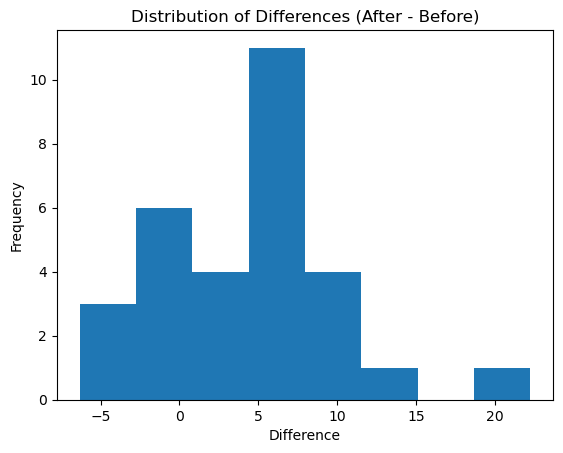

In [27]:
plt.hist(diff, bins = 8)
plt.title("Distribution of Differences (After - Before)")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

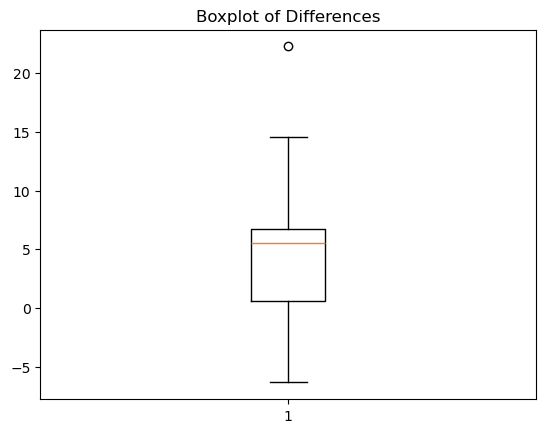

In [28]:
plt.boxplot(diff)
plt.title("Boxplot of Differences")
plt.show()

In [30]:
t_stst, plvalue = st.ttest_rel(after, before)

In [31]:
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.1898917187909754
p-value: 0.030904670013286995


##### Since p-value < 0.05
##### Reject H₀

There is sufficient evidence to conclude that the new workflow tool changed employee productivity (and likely increased it).